In [1]:
import random
from pathlib import Path

import torch

from gcsa.checkpoint import load_checkpoint
from gcsa.msls.dataset import MslsDataset
from gcsa.msls.scene import MslsScene
from gcsa.utils import datasets_dir, outputs_dir
from hloc.visualization import plot_images, read_image

### Load checkpoint

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
checkpoint_path = Path("checkpoints/msls.pth.tar")
model, affinity = load_checkpoint(checkpoint_path, device)

### Create dataset for validation scene

In [3]:
scene = MslsScene("sf", datasets_dir() / "msls", exclude_panos=True, subtask="all")
query_image_paths = scene.query_image_paths()
db_image_paths = scene.db_image_paths()

desc_path = outputs_dir() / "msls" / scene.name / "global-feats-netvlad.h5"
N = max(model.K, model.L)
labels = "dist"
dataset = MslsDataset(scene, desc_path, N, affinity, labels)

### Sample item from dataset

In [4]:
query_idx = random.randint(0, len(dataset) - 1)
desc, labels, aff, db_idx, _ = dataset[query_idx]
labels = labels[1:]

### Results without re-ranking

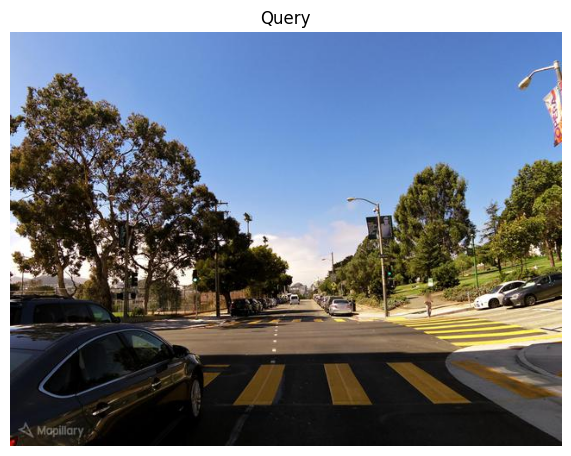

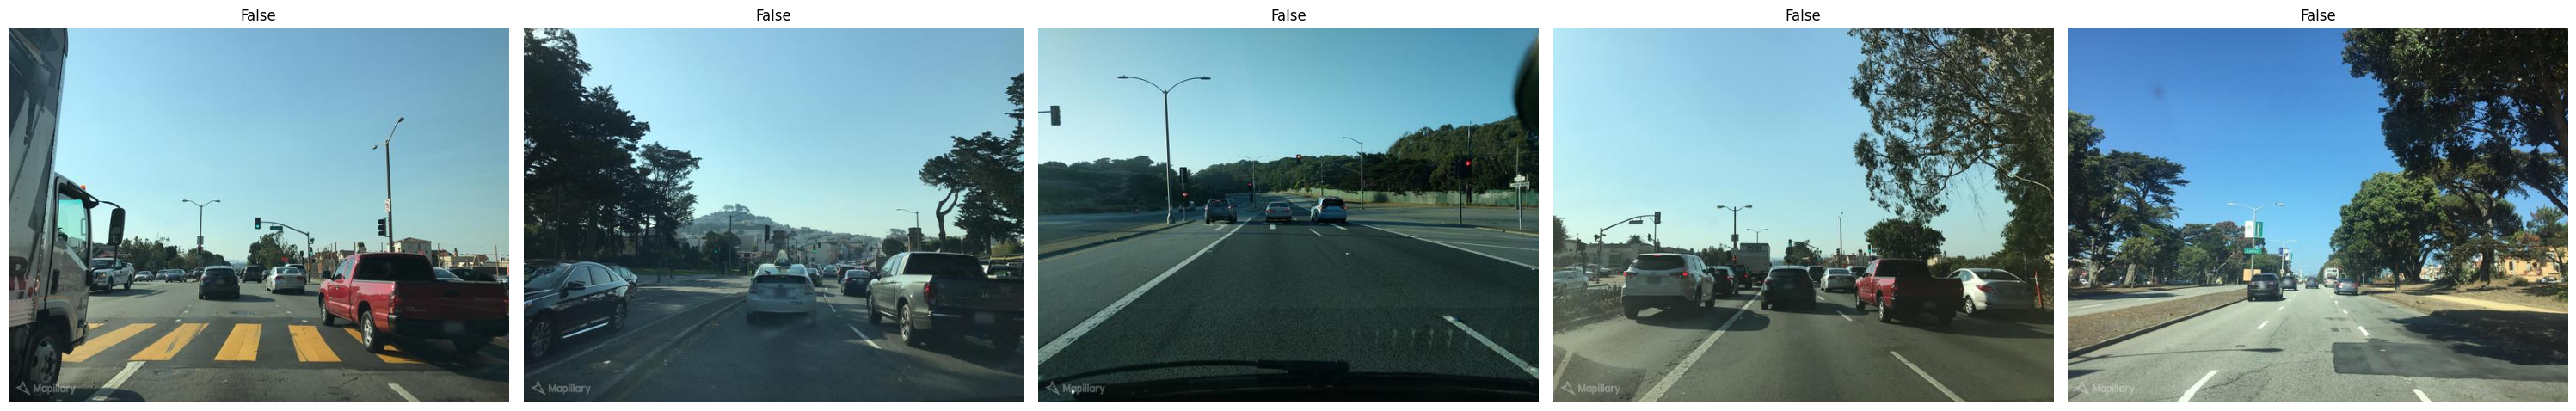

In [5]:
k = 5
plot_images([read_image(scene.image_dir / query_image_paths[query_idx])], titles=["Query"])
plot_images([read_image(scene.image_dir / db_image_paths[db_idx[i]]) for i in range(k)], titles=[str(labels[i].item()) for i in range(k)])

### Results with re-ranking

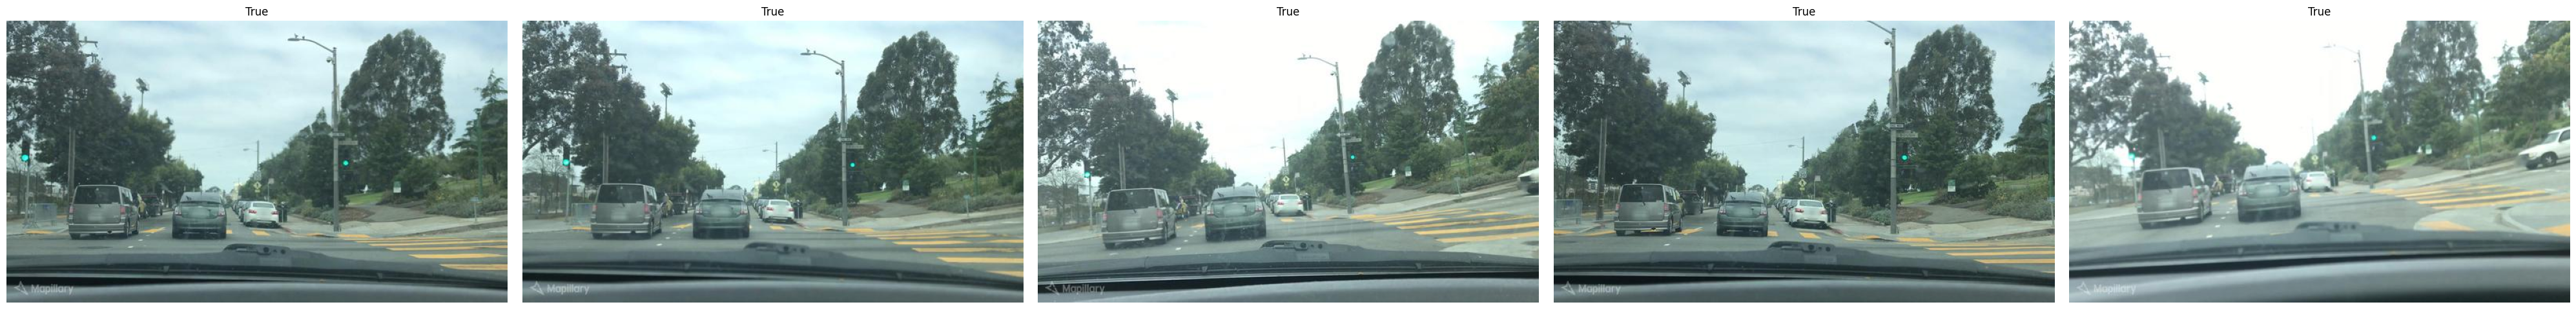

In [6]:
with torch.autocast(device):
    ref_desc = model(desc.unsqueeze(0).to(device), [a.unsqueeze(0).to(device) for a in aff])
ref_desc = ref_desc.squeeze(0)
sim = ref_desc[1:] @ ref_desc[0]
topk_idx = sim.topk(k).indices.cpu()

plot_images([read_image(scene.image_dir / db_image_paths[db_idx[i]]) for i in topk_idx], titles=[str(labels[i].item()) for i in topk_idx])

This demo contains images from the "Mapillary Street-level Sequences Dataset" by Mapillary, licensed under CC BY-NC-SA 4.0.